<a href="https://colab.research.google.com/github/Labgod01/XAI-Documentation/blob/main/User_Input_Implementation_Template_Tabular.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python Unified Implementation Template


# 0. SETUP & DEPENDENCIES

In [ ]:
!pip install -q shap lime dice-ml alibi scikit-learn pandas numpy matplotlib

In [ ]:
import dice_ml
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from alibi.explainers import ALE, AnchorTabular
from lime.lime_tabular import LimeTabularExplainer
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.model_selection import train_test_split

np.random.seed(42)

# 1. UNIFIED USER INPUT


Φόρτωση δοκιμαστικού tabular dataset (California Housing μετατραμμένο σε binary classification):

In [ ]:
raw_data = fetch_california_housing(as_frame=True)
df = raw_data.data.copy()
median_target = raw_data.target.median()
df['is_expensive'] = (raw_data.target > median_target).astype(int)

Εκπαίδευση ενός αντιπροσωπευτικού Tree-based Classifier (Black-Box / Model)

In [ ]:
features_list = [c for c in df.columns if c != 'is_expensive']
clf = RandomForestClassifier(n_estimators=30, max_depth=5, random_state=42)
clf.fit(df[features_list], df['is_expensive'])

RandomForestClassifier(max_depth=5, n_estimators=30, random_state=42)

# UNIFIED USER INPUT

In [ ]:
unified_payload = {
    'model': clf,  # Trained Estimator Object
    'dataset': df,  # Full Reference pandas.DataFrame ???
    'query_instance': df[features_list].iloc[0],  # pandas.Series (Query instance x) ???
    'scope': 'both',  # 'local', 'global', ή 'both'
    'metadata': {
        'target': 'is_expensive',  # Target column string
        'categorical_features': [],  # List of category columns (empty here)
        'immutable_features': [
            'Latitude',
            'Longitude',
        ],  # Locked columns for Counterfactuals
        'target_feature': 'MedInc',  # Feature of interest for ALE & PDP
        'scoring_metric': 'accuracy',  # Evaluation metric for PFI
    },
}

# 2. FRAMEWORK INTERNAL ADAPTER & TRANSFORMER LAYER

In [ ]:
model = unified_payload['model']
df_ref = unified_payload['dataset']
target_col = unified_payload['metadata']['target']
x_query = unified_payload['query_instance']

2.1 Διαχωρισμός χαρακτηριστικών και ετικετών

In [ ]:
X_df = df_ref.drop(columns=[target_col])
y_labels = df_ref[target_col]
feature_names = list(X_df.columns)
target_feature = unified_payload['metadata']['target_feature']

2.2 Αυτόματες μετατροπές δομών δεδομένων (Data Transformations)

In [ ]:
X_np = X_df.values  # 2D NumPy Array for LIME, Anchors, ALE, PDP
x_1d = (
    x_query.values.flatten()
)  # 1D NumPy Array for LIME & Anchors explain_instance
x_2d = x_query.values.reshape(1, -1)  # 2D NumPy Array for SHAP
# If the user provided a Series, convert it using .to_frame().T
# If a DataFrame was already provided, keep it as is (or extract the 1st row):
x_dice_df = (
    x_query.to_frame().T
    if isinstance(x_query, pd.Series)
    else x_query.iloc[[0]]
)  # 2D DataFrame for DiCE

2.3 Background Compression για KernelSHAP (K-Means Centroids)

In [ ]:
kmeans = KMeans(n_clusters=min(100, len(X_df)), random_state=42, n_init='auto')
X_summary_kmeans = kmeans.fit(X_np).cluster_centers_

2.4 Metadata extraction για DiCE

In [ ]:
cat_cols = unified_payload['metadata']['categorical_features']
cont_cols = [c for c in feature_names if c not in cat_cols]
immut_cols = unified_payload['metadata']['immutable_features']
features_to_vary = [c for c in feature_names if c not in immut_cols]

print('>>> Framework Adapter: Data transformations completed successfully.\n')

>>> Framework Adapter: Data transformations completed successfully.



# 3. LOCAL EXPLANATIONS BRANCH (Εκτέλεση Τοπικών Μεθόδων)

In [ ]:
if unified_payload['scope'] in ['local', 'both']:
  print('================= 1. TREE-SHAP (Local) =================')
  tree_explainer = shap.TreeExplainer(model)
  shap_vals = tree_explainer(x_2d)
  print(f'TreeSHAP values shape: {shap_vals.values.shape}')

  print('\n================= 2. KERNEL-SHAP (Local) ================')
  # Χρήση του συμπιεσμένου background set (centroids)
  kernel_explainer = shap.KernelExplainer(
      model.predict_proba, data=X_summary_kmeans
  )
  kernel_vals = kernel_explainer.shap_values(x_2d, nsamples=100)
  print(f'KernelSHAP attributions computed for instance.')

  print('\n================= 3. LIME TABULAR (Local) ===============')
  lime_explainer = LimeTabularExplainer(
      training_data=X_np,
      feature_names=feature_names,
      class_names=['Low', 'High'],
      mode='classification',
      random_state=42,
  )
  exp_lime = lime_explainer.explain_instance(
      data_row=x_1d, predict_fn=model.predict_proba, num_features=5
  )
  print('Top LIME Rules:', exp_lime.as_list())

  print('\n============== 4. DiCE COUNTERFACTUALS (Local) ===========')
  d_dice = dice_ml.Data(
      dataframe=df_ref, continuous_features=cont_cols, outcome_name=target_col
  )
  m_dice = dice_ml.Model(model=model, backend='sklearn')
  exp_dice = dice_ml.Dice(d_dice, m_dice, method='random')
  cf = exp_dice.generate_counterfactuals(
      query_instances=x_dice_df,
      total_CFs=2,
      desired_class='opposite',
      features_to_vary=features_to_vary,
  )
  print('DiCE Counterfactual instances generated successfully.')

  print('\n================= 5. ANCHORS (Local Rules) ===============')
  anchor_explainer = AnchorTabular(
      predictor=model.predict, feature_names=feature_names
  )
  anchor_explainer.fit(X_np)
  exp_anchor = anchor_explainer.explain(x_1d, threshold=0.95)
  print('Anchor Rule:', ' AND '.join(exp_anchor.anchor))

================= 1. TREE-SHAP (Local) =================
TreeSHAP values shape: (1, 8, 2)

================= 2. KERNEL-SHAP (Local) ================


  0%|          | 0/1 [00:00<?, ?it/s]

KernelSHAP attributions computed for instance.

================= 3. LIME TABULAR (Local) ===============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Top LIME Rules: [('MedInc > 4.74', 0.31393073511741687), ('Latitude > 37.71', -0.172512352510722), ('Longitude <= -121.80', 0.08372705239761073), ('AveRooms > 6.05', 0.041996381807224537), ('2.43 < AveOccup <= 2.82', 0.036125505272396066)]

============== 4. DiCE COUNTERFACTUALS (Local) ===========


100%|██████████| 1/1 [00:00<00:00,  4.13it/s]

DiCE Counterfactual instances generated successfully.

================= 5. ANCHORS (Local Rules) ===============
Anchor Rule: MedInc > 4.74 AND AveRooms > 6.05



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/loca

# 4. GLOBAL EXPLANATIONS BRANCH (Εκτέλεση Καθολικών Μεθόδων)

In [ ]:
if unified_payload['scope'] in ['global', 'both']:
  print('\n================= 6. ALE (Global Effects) ===============')
  ale_explainer = ALE(predictor=model.predict_proba, feature_names=feature_names)
  exp_ale = ale_explainer.explain(X=X_np, min_bin_points=10)
  print(f'ALE curve calculated for grid points.')

  print('\n================= 7. PFI (Permutation Importance) =======')
  pfi_result = permutation_importance(
      estimator=model,
      X=X_df,
      y=y_labels,
      scoring=unified_payload['metadata']['scoring_metric'],
      n_repeats=10,
      random_state=42,
  )
  print(
      'Top-3 PFI Mean Drop:',
      np.sort(pfi_result.importances_mean)[::-1][:3],
  )

  print('\n================= 8. PDP & ICE (Global Curves) ==========')
  fig, ax = plt.subplots(figsize=(6, 3))
  # Υποδειγματοληψία 50 παρατηρήσεων για ICE αποφυγή visual clutter
  X_sample = X_df.sample(min(50, len(X_df)), random_state=42)
  PartialDependenceDisplay.from_estimator(
      estimator=model,
      X=X_sample,
      features=[target_feature],
      kind='both',
      grid_resolution=30,
      percentiles=(0.05, 0.95),
      ax=ax,
  )
  plt.close(fig)  # Κλείσιμο plot για αποφυγή popups
  print(f"PDP & ICE curves successfully computed for '{target_feature}'.")

print('\n>>> Execution Pipeline: All selected XAI explanations generated!')


================= 6. ALE (Global Effects) ===============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

ALE curve calculated for grid points.

================= 7. PFI (Permutation Importance) =======
Top-3 PFI Mean Drop: [0.23344477 0.04991764 0.04635174]

================= 8. PDP & ICE (Global Curves) ==========
PDP & ICE curves successfully computed for 'MedInc'.

>>> Execution Pipeline: All selected XAI explanations generated!


Libraries for Explanation Output

In [ ]:
import matplotlib.pyplot as plt
import shap
from alibi.explainers import plot_ale
from sklearn.inspection import PartialDependenceDisplay

# 5. VISUAL OUTPUT GENERATION PIPELINE

5.1 Local Outputs (Εκτελούνται αν scope in ['local', 'both'])


>>> Generating Local Explanation Outputs...


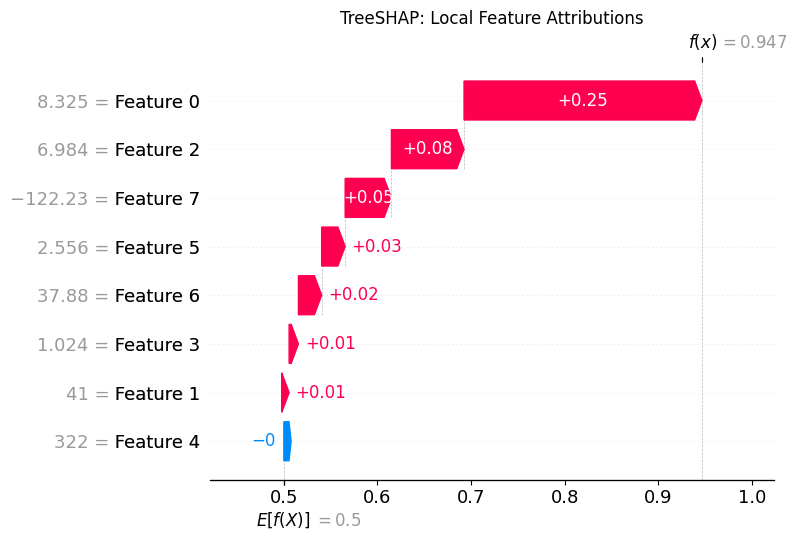

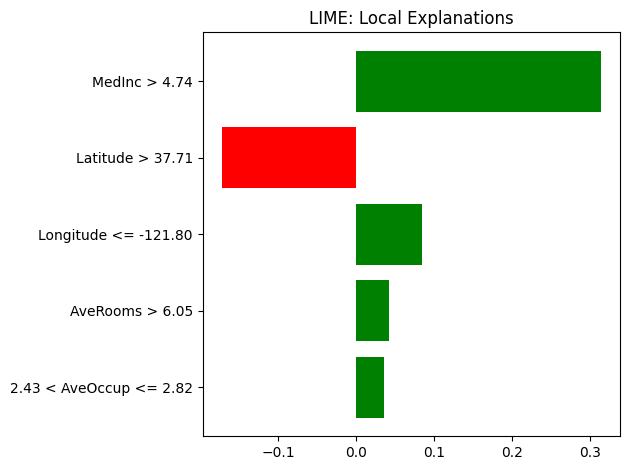


--- DiCE Counterfactual Recourse Instances ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,is_expensive
0,1.0451,41.0,6.984127,1.02381,322.0,2.555556,37.88,-122.23,0
1,0.5736,51.1,6.984127,1.02381,322.0,2.555556,37.88,-122.23,0



--- Anchors Sufficient Rule ---
Rule: MedInc > 4.74 AND AveRooms > 6.05
Precision: 0.99 | Coverage: 0.25


In [ ]:
if unified_payload['scope'] in ['local', 'both']:
  print('\n>>> Generating Local Explanation Outputs...')

  # 1. TreeSHAP Waterfall Plot
  plt.figure()
  shap.plots.waterfall(shap_vals[0, :, 1], show=False)
  plt.title('TreeSHAP: Local Feature Attributions')
  plt.tight_layout()
  plt.show()

  # 2. LIME Horizontal Bar Plot
  fig = exp_lime.as_pyplot_figure()
  plt.title('LIME: Local Explanations')
  plt.tight_layout()
  plt.show()

  # 3. DiCE Counterfactuals Tabular Output
  print('\n--- DiCE Counterfactual Recourse Instances ---')
  cf_df = cf.cf_examples_list[0].final_cfs_df
  display(cf_df)  # Εμφανίζει τον πίνακα αντιπαραδειγμάτων

  # 4. Anchors High-Precision Rule Output
  print('\n--- Anchors Sufficient Rule ---')
  print(f'Rule: {" AND ".join(exp_anchor.anchor)}')
  print(f'Precision: {exp_anchor.precision:.2f} | Coverage: {exp_anchor.coverage:.2f}')

5.2 Global Outputs (Εκτελούνται αν scope in ['global', 'both'])


>>> Generating Global Explanation Outputs...


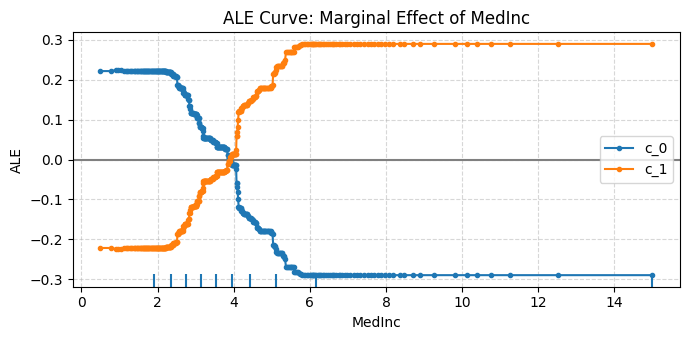

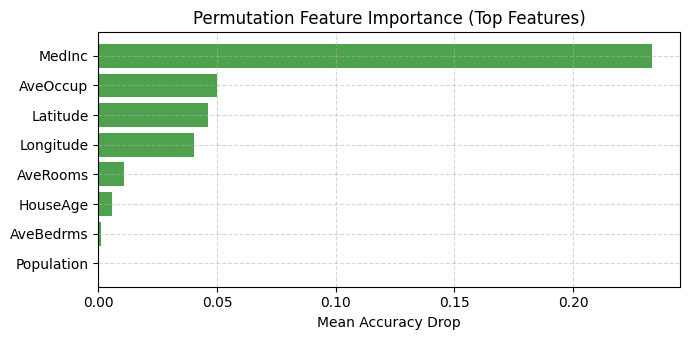

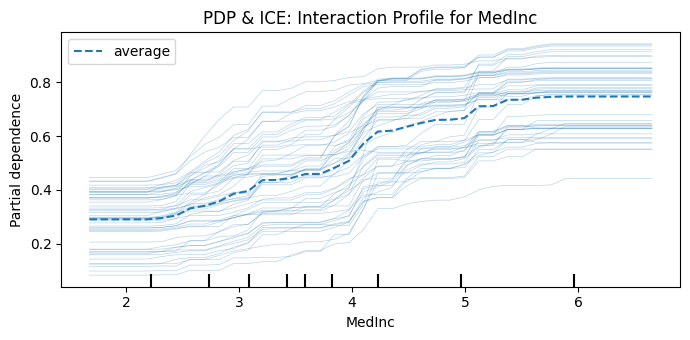


>>> All visual and tabular outputs rendered successfully.


In [ ]:
if unified_payload['scope'] in ['global', 'both']:
  print('\n>>> Generating Global Explanation Outputs...')

  # 5. ALE Plot (1D Centered Curve)
  fig, ax = plt.subplots(figsize=(7, 3.5))
  plot_ale(exp_ale, features=[target_feature], ax=ax)
  ax.set_title(f'ALE Curve: Marginal Effect of {target_feature}')
  ax.grid(True, linestyle='--', alpha=0.5)
  plt.tight_layout()
  plt.show()

  # 6. PFI Sorted Bar Plot
  sorted_idx = pfi_result.importances_mean.argsort()[::-1]
  plt.figure(figsize=(7, 3.5))
  plt.barh(
      np.array(feature_names)[sorted_idx][:8],
      pfi_result.importances_mean[sorted_idx][:8],
      color='forestgreen',
      alpha=0.8,
  )
  plt.gca().invert_yaxis()
  plt.xlabel('Mean Accuracy Drop')
  plt.title('Permutation Feature Importance (Top Features)')
  plt.grid(True, linestyle='--', alpha=0.5)
  plt.tight_layout()
  plt.show()

  # 7. PDP & ICE Joint Curves
  fig, ax = plt.subplots(figsize=(7, 3.5))
  PartialDependenceDisplay.from_estimator(
      estimator=model,
      X=X_sample,
      features=[target_feature],
      kind='both',  # Εμφάνιση ICE (λεπτές γραμμές) + PDP (έντονη γραμμή)
      grid_resolution=40,
      percentiles=(0.05, 0.95),
      ax=ax,
  )
  ax.set_title(f'PDP & ICE: Interaction Profile for {target_feature}')
  plt.tight_layout()
  plt.show()

print('\n>>> All visual and tabular outputs rendered successfully.')